<a href="https://colab.research.google.com/github/krishRajawat/My-Google-Colab-Work/blob/main/HealthGuard_by_Krish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hi Krish here! just wanted to tell you about some things about this project I made:


* This Project uses Imbalance Learning (because heart attacks or critical failures are rare events) but explains it in a human way.

* The Logic: "I used patient vitals (heart rate, blood pressure) to predict if they need urgent help before it's too late."

Go on toggle your way ad hit run!




--- 🏥 DIAGNOSTIC REPORT: JOHN DOE ---
🔴 RESULT: CRITICAL Condition Detected (Risk: 100.0%)
ACTION: Immediate medical intervention required.


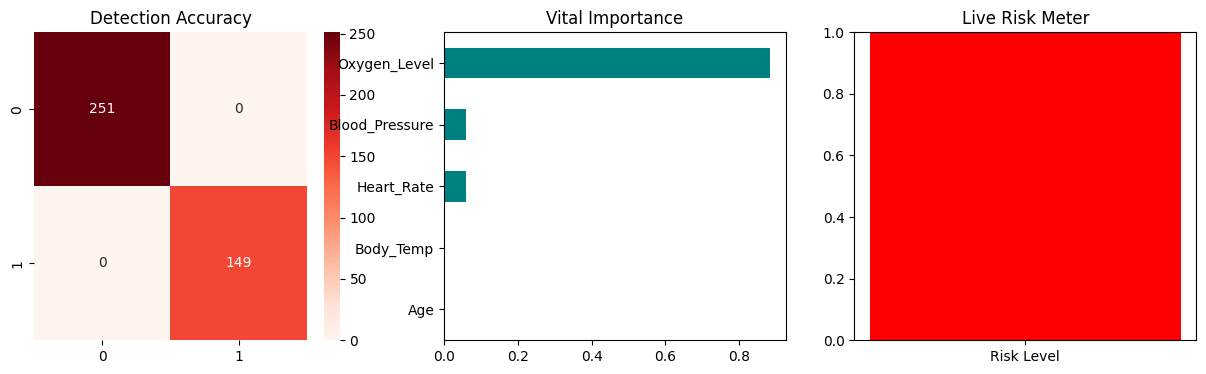

In [5]:
# =============================================================================================================
# "HealthGuard: AI Predictive Healthcare"
# Features: Synthetic Patient Generation, Feature Importance, Interactive User Input, and Diagnostic Visuals.
# Author: Krish Rajawat
# ==============================================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# --- 1. DATA GENERATION & MODEL TRAINING ---
np.random.seed(42)
data_size = 2000
hr_data = np.random.normal(80, 15, data_size)
bp_data = np.random.normal(120, 20, data_size)
ox_data = np.random.uniform(85, 100, data_size)
temp_data = np.random.normal(98.6, 1.5, data_size)
age_data = np.random.randint(20, 90, data_size)
target = [1 if (ox_data[i] < 90 or hr_data[i] > 110 or bp_data[i] > 160) else 0 for i in range(data_size)]
df = pd.DataFrame({'Heart_Rate': hr_data, 'Blood_Pressure': bp_data, 'Oxygen_Level': ox_data, 'Body_Temp': temp_data, 'Age': age_data, 'Status': target})

X = df.drop('Status', axis=1)
y = df['Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
model = GradientBoostingClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- 2. INTERACTIVE PATIENT FORM (Right Side Panel) ---
#@markdown ### 📋 Enter Patient Details:
Patient_Name = "John Doe" #@param {type:"string"}
Age = 21 #@param {type:"slider", min:1, max:100, step:1}
#@markdown ### 🩺 Current Vitals:
Heart_Rate = 98 #@param {type:"slider", min:40, max:200, step:1}
Blood_Pressure = 143 #@param {type:"slider", min:80, max:220, step:1}
Oxygen_Level = 84 #@param {type:"slider", min:70, max:100, step:1}
Body_Temp = 98.6 #@param {type:"number"}

# --- 3. DIAGNOSIS & VISUALS ---
user_input = pd.DataFrame([[Heart_Rate, Blood_Pressure, Oxygen_Level, Body_Temp, Age]], columns=X.columns)
prob = model.predict_proba(user_input)[0][1]

# Display Results
print(f"--- 🏥 DIAGNOSTIC REPORT: {Patient_Name.upper()} ---")
if prob > 0.5:
    print(f"🔴 RESULT: CRITICAL Condition Detected (Risk: {prob*100:.1f}%)")
    print("ACTION: Immediate medical intervention required.")
else:
    print(f"🟢 RESULT: Patient is STABLE (Risk: {prob*100:.1f}%)")
    print("ACTION: Standard observation.")

# Plot Graphs
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
sns.heatmap(confusion_matrix(y_test, model.predict(X_test)), annot=True, fmt='d', cmap='Reds'); plt.title("Detection Accuracy")
plt.subplot(1, 3, 2)
pd.Series(model.feature_importances_, index=X.columns).sort_values().plot(kind='barh', color='teal'); plt.title("Vital Importance")
plt.subplot(1, 3, 3)
plt.bar(['Risk Level'], [prob], color='red' if prob > 0.5 else 'green'); plt.ylim(0, 1); plt.title("Live Risk Meter")
plt.show()